In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
import plotly.express as px
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,r2_score, classification_report, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [13]:
df= pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [14]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [18]:
df= pd.get_dummies(df, columns=["gender", "platform_usage","social_interaction_level" ])
y= df["depression_label"]
x= df.drop(["depression_label"], axis=1)

      age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0      14                       7.9          7.4                       2.9   
1      19                       1.9          8.0                       2.9   
2      17                       1.3          7.6                       0.5   
3      15                       7.4          6.9                       1.6   
4      15                       4.7          4.9                       3.0   
...   ...                       ...          ...                       ...   
1195   18                       6.8          6.6                       2.0   
1196   16                       2.3          8.0                       1.9   
1197   14                       1.7          8.7                       0.7   
1198   15                       3.9          8.5                       2.1   
1199   16                       4.7          6.5                       1.0   

      academic_performance  physical_activity  stress_level  an

In [66]:
mx= 0
svm = SVC(C=1)
acc_score_svm=[]
model= ["svm"]*5
ls= [0.05, 0.1,0.15,0.2,0.25]
for i in ls:
    x_train, x_test, y_train, y_test=train_test_split(x, y, test_size= i, random_state=42)
    svm.fit(x_train,y_train)
    y_pred= svm.predict(x_test)
    acc= accuracy_score(y_test, y_pred)
    acc_score_svm.append(acc)
    if mx<acc:
        idx= i 
    mx_svm= max(mx, acc)
print("max for SVM : ", idx, mx)
df_svm = pd.DataFrame({"model":model, "test size":ls, "accuracy score":acc_score_svm})

max for SVM :  0.25 0


In [67]:
mx=0
acc_score_dstree=[]
model= ["desicion tree"]*5

for i in ls:
    x_train, x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=i)
    dt= DecisionTreeClassifier(criterion="entropy", max_depth= 3, random_state= 42)
    dt.fit(x_train, y_train)
    y_pred=dt.predict(x_test)
    acc= accuracy_score(y_test, y_pred)
    acc_score_dstree.append(acc)
    if mx< acc:
        idx= i
    mx_dt= max(mx, acc)
print("max for DecisionTreeClassifier", idx, mx)
df_dt = pd.DataFrame({"model":model, "test size":ls, "accuracy score":acc_score_dstree})


max for DecisionTreeClassifier 0.25 0


In [68]:
mx=0
acc_score_stdScalerKNN= []
scaler= StandardScaler()

for i in ls:
    x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=i, random_state=42)
    x_train_scale= scaler.fit_transform(x_train)
    x_test_scale= scaler.transform(x_test) 
    knn= KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train_scale, y_train)
    y_pred= knn.predict(x_test_scale)
    acc= accuracy_score(y_test, y_pred)
    acc_score_stdScalerKNN.append(acc)
    if mx<acc:
        idx=i
    mx_knn= max(mx, acc)
print(acc_score_stdScalerKNN)
model= ["knn"]*5
df_knn = pd.DataFrame({"model":model, "test size":ls, "accuracy score":acc_score_stdScalerKNN})

print("for knn : ", idx, mx)

[0.9333333333333333, 0.9583333333333334, 0.9722222222222222, 0.975, 0.9733333333333334]
for knn :  0.25 0


In [69]:
mx= 0
acc_score_rd= []
for i in ls:
    x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=i ,random_state=42)
    rf= RandomForestClassifier(n_estimators=100,
                              criterion = "gini",
                              max_depth=None,
                              random_state=42)
    rf.fit(x_train, y_train)
    y_pred= rf.predict(x_test)
    acc= accuracy_score(y_test, y_pred)
    acc_score_rd.append(acc)
    if mx<acc:
        idx=i
    mx_rd= max(mx,acc)
model= ["random forest"]*5
df_rf = pd.DataFrame({"model":model, "test size":ls, "accuracy score":acc_score_rd})
print("for random forest", idx, mx)

for random forest 0.25 0


In [70]:
mx= 0
r2= []
ms1=[]
acc_score_lr= []
for i in ls:
    x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=i ,random_state=42)
    model= LinearRegression()
    model.fit(x_train, y_train)
    y_pred= rf.predict(x_test)
    acc= accuracy_score(y_test, y_pred)
    acc_score_lr.append(acc)
    r2s= r2_score(y_test, y_pred)
    ms= mean_squared_error(y_test,y_pred)
    ms1.append(ms)
    r2.append(r2s)
    if mx<acc:
        idx=i
    mx_lr= max(mx,acc)
model= ["Linear regression"]*5
df_lr = pd.DataFrame({"model":model, "test size":ls, "accuracy score":acc_score_lr})
print("for linear regression", idx, mx)
df_lr_r2= pd.DataFrame({"model":model, "test size":ls, "r2 score":r2})
df_lr_mse= pd.DataFrame({"model":model, "test size":ls, "Mean Squared Error":ms1})

for linear regression 0.25 0


In [72]:
combined_df = pd.concat([df_knn, df_lr, df_rf, df_dt, df_svm], ignore_index=True)
mse_df= pd.concat([df_lr_mse, df_pr_mse], ignore_index= True)
mx_df= pd.DataFrame({"model": ["svm", "Decision tree", "KNN" ,"randoe Forest", "Linear Regression"], "Max Accuracy":[mx_svm , mx_dt, mx_knn, mx_rd, mx_lr]})

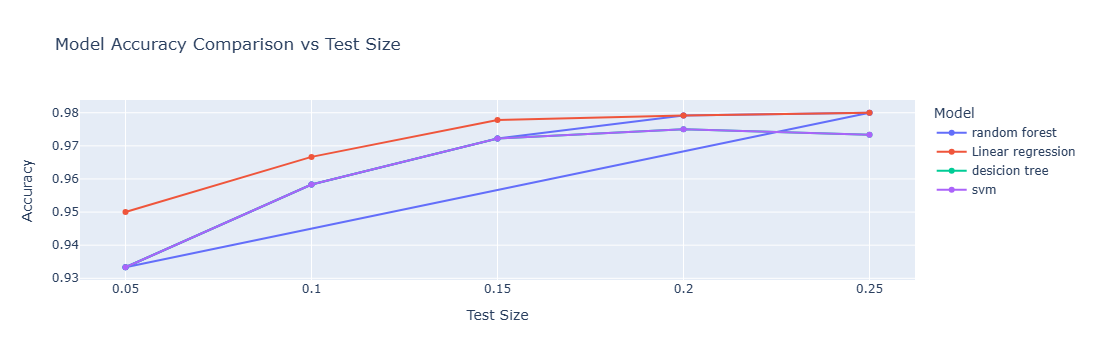

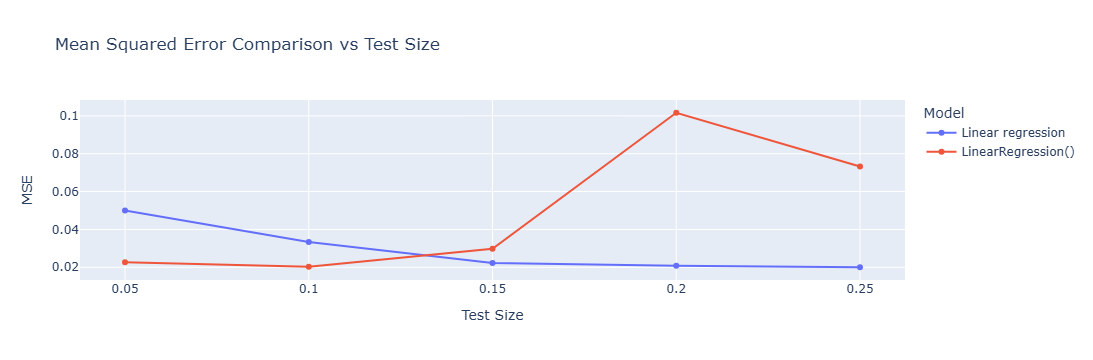

In [64]:
fig = px.line(
    combined_df,
    x="test size",
    y="accuracy score",
    color="model",   
    markers=True,    
    title="Model Accuracy Comparison vs Test Size"
)


fig.update_layout(
    xaxis_title="Test Size",
    yaxis_title="Accuracy",
    legend_title="Model"
)

fig.show()
fig = px.line(
   mse_df,
    x="test size",
    y="Mean Squared Error",
    color="model",   
    markers=True,    
    title="Mean Squared Error Comparison vs Test Size"
)


fig.update_layout(
    xaxis_title="Test Size",
    yaxis_title="MSE",
    legend_title="Model"
)

fig.show()

In [60]:
mx= 0
pl_reg_acc=[]
ms2=[]
for i in range(1,6):
    x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.2, random_state=42)
    poly= PolynomialFeatures(degree=i)
    
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly= poly.transform(x_test)
    model  = LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred_poly= model.predict(x_test_poly)
    r2=r2_score(y_test, y_pred_poly)
    ms22= mean_squared_error(y_test,y_pred_poly)
    ms2.append(ms22)
    if mx<r2:
        bestdeg=i
        mx=r2
print(mx, bestdeg)
df_pr_mse= pd.DataFrame({"model":model, "test size":ls, "Mean Squared Error":ms2})


0.16947687279411128 2


In [54]:
acc_poly=[]
for i in ls:
    x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=i, random_state=42)
    poly= PolynomialFeatures(degree=2)
    
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly= poly.transform(x_test)
    model  = LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred_poly= model.predict(x_test_poly)
    acc=r2_score(y_test, y_pred_poly)
    acc_poly.append(acc)
    if mx<acc:
        mx=acc
model = ["Polynomial regression"]*5
df_pr=pd.DataFrame({"model":model , "test size": ls, "r2 score": acc_poly})

In [56]:
df_com_lr= pd.concat([df_pr, df_lr_r2], ignore_index=True)

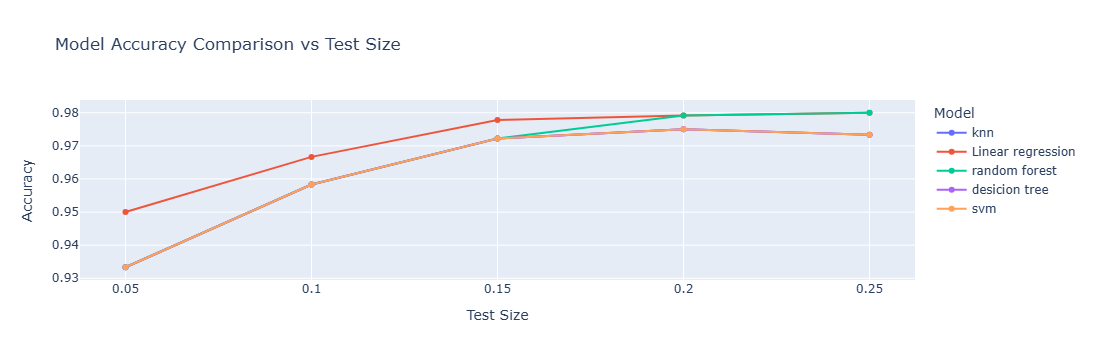

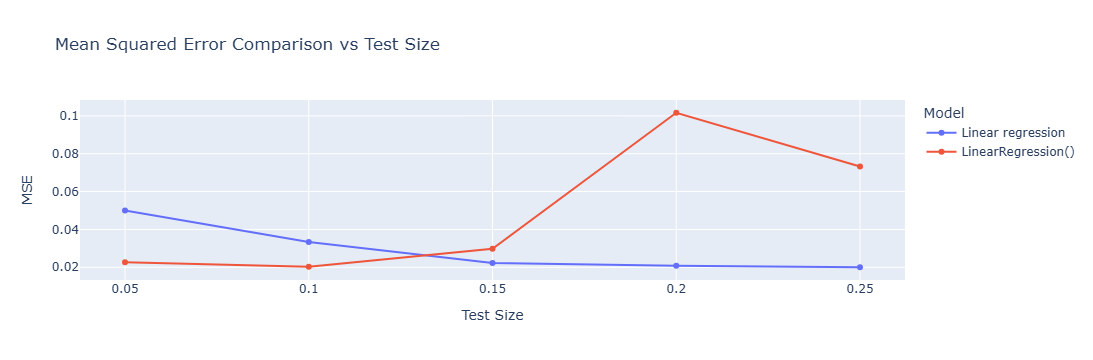

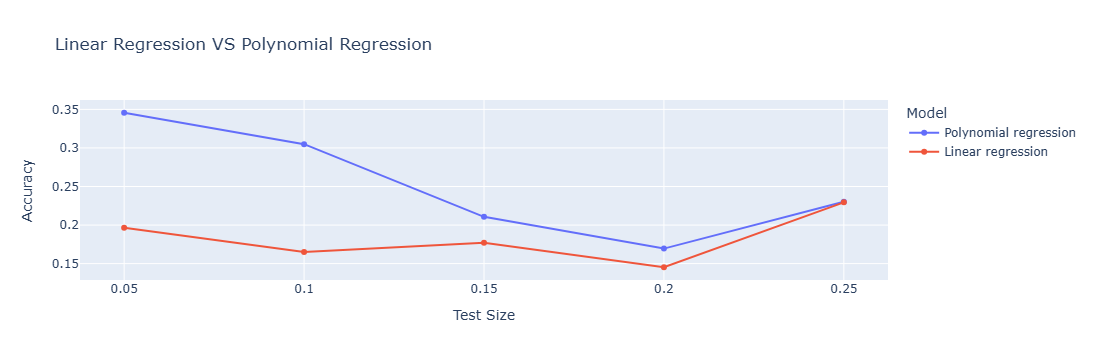

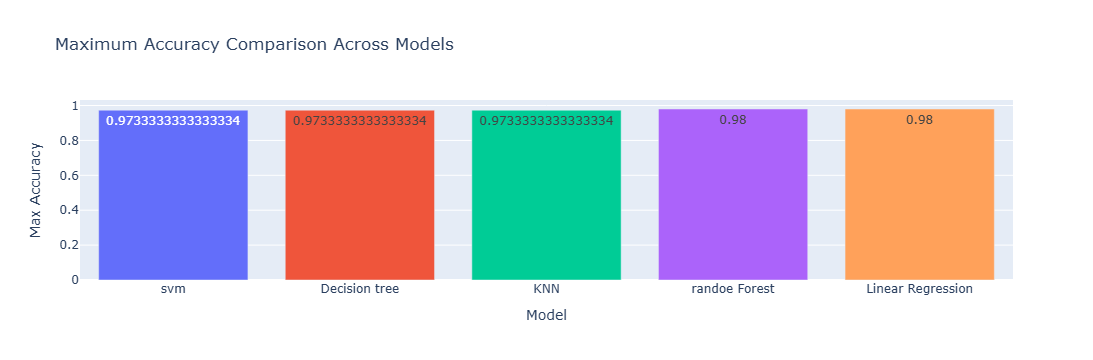

In [73]:
fig = px.line(
    combined_df,
    x="test size",
    y="accuracy score",
    color="model",   
    markers=True,    
    title="Model Accuracy Comparison vs Test Size"
)


fig.update_layout(
    xaxis_title="Test Size",
    yaxis_title="Accuracy",
    legend_title="Model"
)

fig.show()
fig = px.line(
   mse_df,
    x="test size",
    y="Mean Squared Error",
    color="model",   
    markers=True,    
    title="Mean Squared Error Comparison vs Test Size"
)


fig.update_layout(
    xaxis_title="Test Size",
    yaxis_title="MSE",
    legend_title="Model"
)

fig.show()
fig = px.line(
    df_com_lr,
    x="test size",
    y="r2 score",
    color="model",   
    markers=True,    
    title="Linear Regression VS Polynomial Regression"
)


fig.update_layout(
    xaxis_title="Test Size",
    yaxis_title="Accuracy",
    legend_title="Model"
)

fig.show()
fig = px.bar(
    mx_df,
    x="model",
    y="Max Accuracy",
    color="model",  # optional: gives each bar a different color
    title="Maximum Accuracy Comparison Across Models",
    text="Max Accuracy"  # show accuracy values on top of bars
)

# Customize layout
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Max Accuracy",
    showlegend=False  # hide legend since model names are already on x-axis
)

fig.show()